In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('/content/student_performance.csv')

df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [9]:
df['total_score'] = df['math_score'] + df['programming_score']

In [10]:
conn = sqlite3.connect('student.db')

df.to_sql('students', conn, if_exists='replace', index=False)

print("Database connected successfully!")

Database connected successfully!


In [11]:
# Panel 1 data: avg math by department
query1 = """
SELECT department,
ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department;
"""

avg_math = pd.read_sql_query(query1, conn)

# Panel 2 data: student count by department
query2 = """
SELECT department,
COUNT(*) AS student_count
FROM students
GROUP BY department;
"""

student_count = pd.read_sql_query(query2, conn)

# Panel 3 data: top 8 students by total score
query3 = """
SELECT name,
total_score
FROM students
ORDER BY total_score DESC
LIMIT 8;
"""

top_students = pd.read_sql_query(query3, conn)

# Panel 4 data: gender-wise average attendance
query4 = """
SELECT gender,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender;
"""

gender_attendance = pd.read_sql_query(query4, conn)

print("SQL Queries Executed Successfully!")

SQL Queries Executed Successfully!


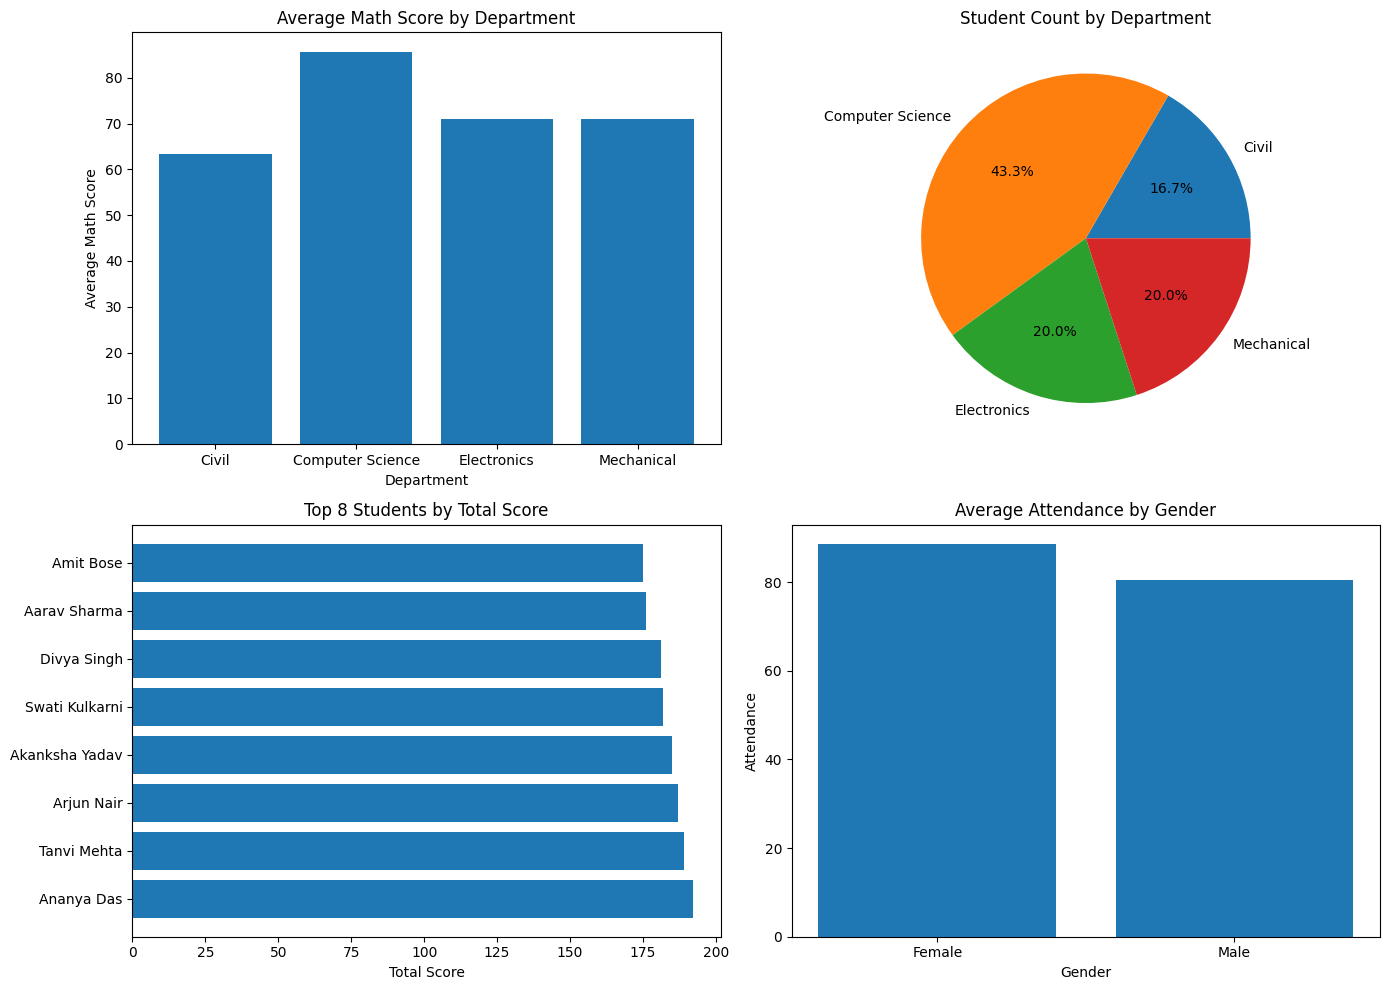

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1 (top-left): Avg Math by Department - BAR Chart ──
axs[0,0].bar(avg_math['department'], avg_math['avg_math'])

axs[0,0].set_title('Average Math Score by Department')
axs[0,0].set_xlabel('Department')
axs[0,0].set_ylabel('Average Math Score')

# ── Panel 2 (top-right): Student Count Pie Chart ──
axs[0,1].pie(
    student_count['student_count'],
    labels=student_count['department'],
    autopct='%1.1f%%'
)

axs[0,1].set_title('Student Count by Department')

# ── Panel 3 (bottom-left): Top 8 Students Horizontal Bar ──
axs[1,0].barh(
    top_students['name'],
    top_students['total_score']
)

axs[1,0].set_title('Top 8 Students by Total Score')
axs[1,0].set_xlabel('Total Score')

# ── Panel 4 (bottom-right): Gender Avg Attendance Bar ──
axs[1,1].bar(
    gender_attendance['gender'],
    gender_attendance['avg_attendance']
)

axs[1,1].set_title('Average Attendance by Gender')
axs[1,1].set_xlabel('Gender')
axs[1,1].set_ylabel('Attendance')

plt.tight_layout()

plt.show()

# Question 1

SELECT AVG(programming_score)
FROM students
WHERE gender = 'Female';

# Question 2

WHERE filters rows before grouping.

Example:
SELECT * FROM students
WHERE math_score > 80;

HAVING filters groups after GROUP BY.

Example:
SELECT department, AVG(math_score)
FROM students
GROUP BY department
HAVING AVG(math_score) > 75;

# Question 3

SELECT department,
AVG(attendance_percentage)
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85;

# Question 4

pd.read_sql_query() returns SQL data as a Pandas DataFrame.

It requires:
1. SQL Query
2. Database Connection

# Question 5

SELECT department,
ROUND(AVG(programming_score),2) AS avg_programming
FROM students
GROUP BY department;